# Instruction of the Code
## The code include three mainly function
* convolution(img,k)  #k is the kernel
* successiveMM(img,A,B)  #successive convolution, A is the first kernel, B is the second
## How to run the code
* Directly run all cells, the result of each part will show on the screen
* All the image will be saved automatically with name as part#-##.png 
## Read The Image
change the path at Read Image

# Convolution. (Use Dataset A)
Convolution provides a way of multiplying two arrays to produce a third array. Depending on the designed 
filter and the intended effect, the kernel can be a matrix of dimensions, for example, 3x3, 5x5 or 7x7.

In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
#import libraries
import numpy as np
import math
from PIL import Image
import cv2
import matplotlib.pyplot as plt

## Read Image

In [3]:
img=cv2.imread("datasetA/car-2.jpg")

## Part A
Code a function that takes an input image, performs convolution with a given kernel, and returns the 
resulting image.

In [4]:
def zeropad(img,N):
    #TO_DO: create a new image with zero padding
    #N is window's size
    height,width,channel=img.shape
    padding=(N//2)
    img_zero=np.zeros((height+padding*2,width+padding*2,channel))
    for y in range(height):
        for x in range(width):
            img_zero[y+padding][x+padding]=img[y][x]
    return img_zero.astype("uint8")

In [5]:
def convolution(img,k):
    #Apply zero padding to the image
    N=len(k)
    img_zero=zeropad(img,N)
    
    #create output image
    height,width,channel=img.shape
    output=np.zeros((height,width,channel))

    #doing convolution to image:
    for y in range(height):
        for x in range(width):
            add=np.array([0.0,0.0,0.0])
            for i in range(N):
                add+=k[i]@img_zero[y+i][x:x+N]

            #limit the value between [0,255]
            for j in range(len(add)):
                if add[j]>255:
                    add[j]=255
                elif add[j]<0:
                    add[j]=0
                    
            output[y][x]=add
            
    return output.astype("uint8")

## Part B
Design a convolution kernel that computes, for each pixel, the average intensity value in a 3x3 region. 
Use this kernel and the filtering function above, and save the resulting image. 

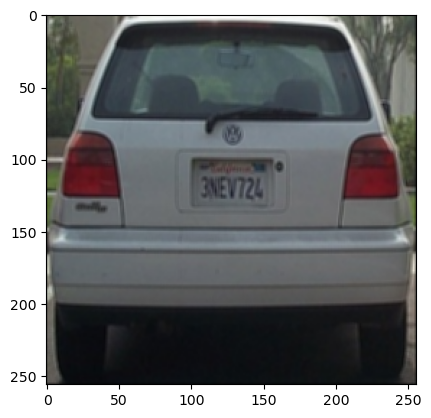

In [6]:
k_average=np.ones((3,3))/9

output=convolution(img,k_average)
image_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
plt.title("Image after k_average")
plt.imshow(image_rgb)
plt.savefig('partB.png')

## Part C
Use the kernels provided below, apply the filtering function and save the resulting images. Comment on the effect of each kernel.

$A=\begin{bmatrix}1&2&1\\2&4&2\\1&2&1\end{bmatrix}$
$B=\begin{bmatrix}0&1&0\\1&-4&1\\0&1&0\end{bmatrix}$

In [7]:
A=np.array([[1,2,1],[2,4,2],[1,2,1]])/16
B=np.array([[0,1,0],[1,-4,1],[0,1,0]])

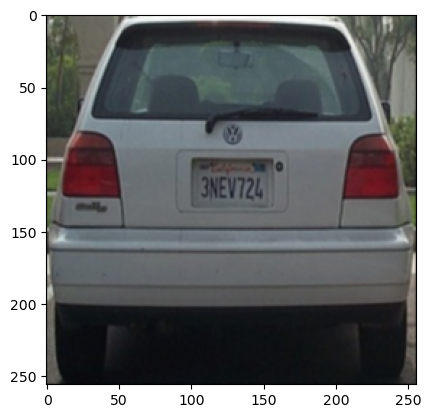

In [14]:
outputA=convolution(img,A)
plt.imshow(cv2.cvtColor(outputA, cv2.COLOR_RGB2BGR))
plt.savefig('partC-A.png')

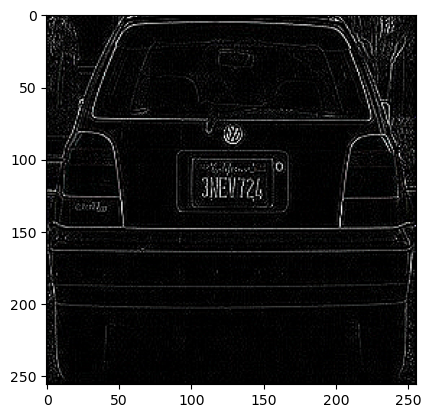

In [15]:
outputB=convolution(img,B)
plt.imshow(cv2.cvtColor(outputB, cv2.COLOR_BGR2RGB))
plt.savefig('partC-B.png')

## Part D
Use the filtering function for the following filtering operations: (i) A followed by A; (ii) A followed by B; 
(iii) B followed by A. Comment the results. 

In [10]:
def successiveMM(img,A,B):
    output1=convolution(img,A)
    output2=convolution(output1,B)
    plt.imshow(cv2.cvtColor(output2, cv2.COLOR_BGR2RGB))
    return output2

Text(0.5, 1.0, 'once 7x7 gaussian')

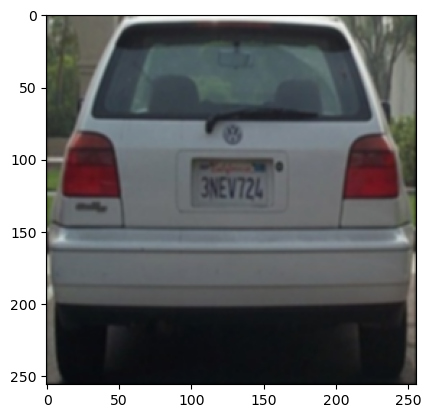

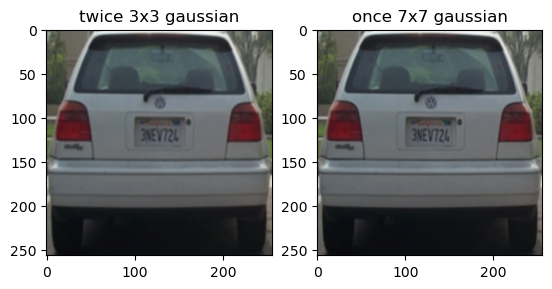

In [16]:
_=successiveMM(img,A,A)
outputAA=convolution(outputA,A)
plt.savefig('partD-AA.png')
first=cv2.GaussianBlur(img, (3,3),1)
second=cv2.GaussianBlur(first, (3,3),1)
plt.figure()
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(second, cv2.COLOR_BGR2RGB))
plt.title("twice 3x3 gaussian")
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(cv2.GaussianBlur(img, (7,7),1), cv2.COLOR_BGR2RGB))
plt.title("once 7x7 gaussian")

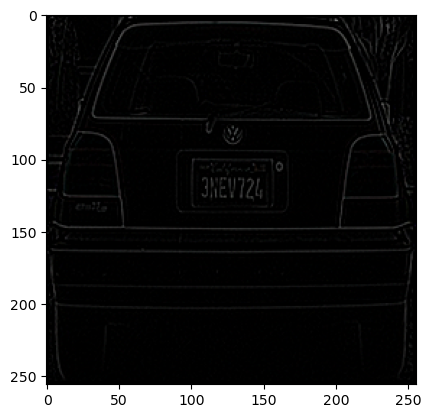

In [17]:
_=successiveMM(img,A,B)
plt.savefig('partD-AB.png')

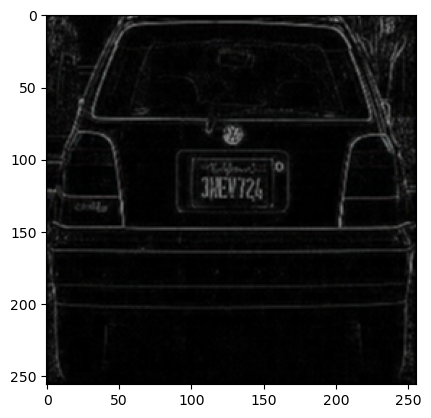

In [18]:
_=successiveMM(img,B,A)
plt.savefig('partD-BA.png')